# Partie 1 – Graphique linéaire (Line Plot) 
1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.
2) Identifier visuellement les valeurs qui semblent anormales. 

## 1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.

In [1]:
# charger les bibliothèques nécessaires
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
#charger les données depuis le fichier CSV
df = pd.read_csv('../data/mesures_capteurs.csv')
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    object 
 1   date_heure    605 non-null    object 
 2   id_capteur    605 non-null    object 
 3   batiment      605 non-null    object 
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    object 
dtypes: float64(4), object(5)
memory usage: 42.7+ KB


In [12]:
#convertire la colonne date-heure en format datetime
#data['date-heure'] = pd.to_datetime(data['date-heure'])
df["date_heure"] = pd.to_datetime(df["date_heure"])


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    object        
 1   date_heure    605 non-null    datetime64[ns]
 2   id_capteur    605 non-null    object        
 3   batiment      605 non-null    object        
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 42.7+ KB


In [18]:
#trier les ligne suivant la  chronologie pour suivre laffichage dans le temps 
df = df.sort_values(by="date_heure")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
150,M0001,2026-01-05 00:00:00,C001,B001,24.91,54.60,1019.00,222.33,OK
547,M0002,2026-01-05 01:00:00,C002,B001,18.15,51.98,1014.02,165.77,OK
20,M0003,2026-01-05 02:00:00,C003,B001,23.95,56.47,1020.04,215.00,OK
282,M0004,2026-01-05 03:00:00,C004,B002,26.20,76.27,1016.74,191.33,OK
484,M0005,2026-01-05 04:00:00,C005,B002,27.11,55.41,1020.03,227.75,OK


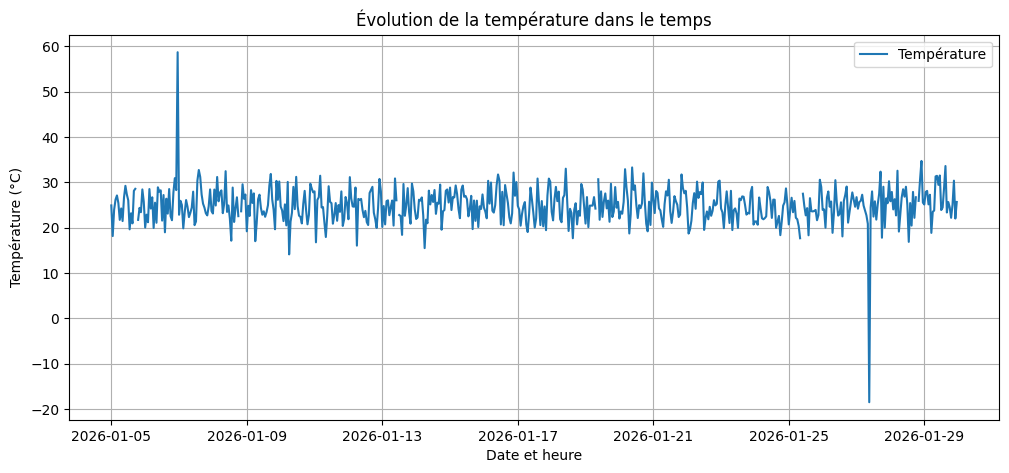

In [19]:
#1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], label="Température")

plt.title("Évolution de la température dans le temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)

plt.show()

## 2) Identifier visuellement les valeurs qui semblent anormales. 

## 2) Identifier visuellement les valeurs qui semblent anormales. 


On observe deux anomalies très nettes sur la courbe : un pic autour du 6-7 janvier 
atteignant environ 58-60°C, et une chute autour du 27-28 janvier descendant à 
environ -20°C. Ces deux valeurs sont totalement incohérentes avec le comportement 
normal des données (qui oscillent entre 15 et 30°C) et apparaissent de façon isolée, 
ce qui suggère des erreurs de mesure plutôt que de vraies variations climatiques.

# Partie 2 – Diagramme en barres (Bar Chart) 
1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments 
2) Comparer graphiquement la consommation moyenne des bâtiments 
3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal 
4) Dans quels cas un graphique horizontal peut-il être plus lisible ? 

## 1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments 


In [20]:
#1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments 
consommation_batiment = df.groupby('batiment')['consommation'].mean()
consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

## 2) Comparer graphiquement la consommation moyenne des bâtiments 


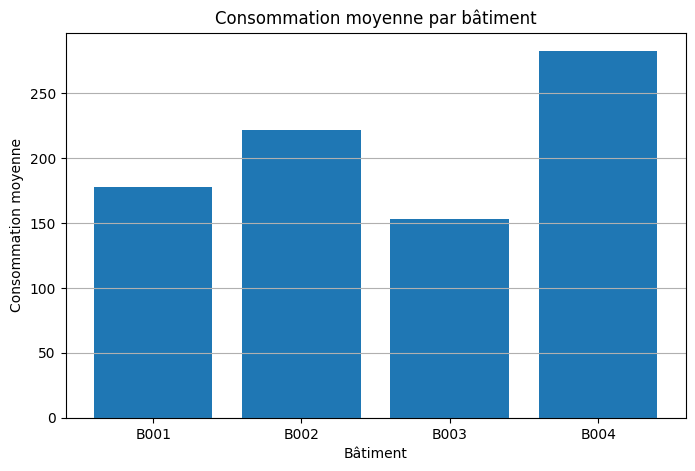

In [21]:
#2) Comparer graphiquement la consommation moyenne des bâtiments 
plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values)

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne")
plt.grid(axis="y")

plt.show()


##  2) : Comparaison de la consommation moyenne par bâtiment


## Question 2 : Comparaison de la consommation moyenne par bâtiment

B004 consomme le plus en moyenne (282.55), suivi de B002 (221.79) et B001 
(177.87), tandis que B003 consomme le moins (153.19). B004 se démarque 
nettement des autres, avec près de deux fois plus que B003 — un écart qui 
rejoint l'anomalie déjà repérée sur ce bâtiment en Partie 7.

## 3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal 


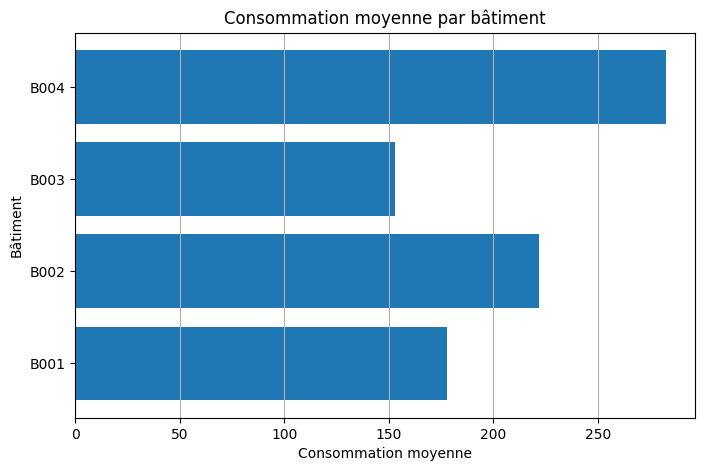

In [22]:
#3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal 

plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values)

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Consommation moyenne")
plt.ylabel("Bâtiment")
plt.grid(axis="x")

plt.show()


## 4) Dans quels cas un graphique horizontal peut-il être plus lisible ? 


## 4) Dans quels cas un graphique horizontal peut-il être plus lisible ? 

Un graphique horizontal peut être plus lisible dans plusieurs cas :

- Étiquettes longues : quand les noms de catégories sont longs et se superposent 
  ou nécessitent une rotation difficile à lire sur un axe X (peu pertinent ici, 
  les noms de bâtiments sont courts).
- Grand nombre de catégories : au-delà d'une dizaine d'éléments, une disposition 
  verticale étire trop l'axe horizontal (non applicable ici avec seulement 4 bâtiments).
- Classements : pour trier les données de haut en bas, du plus grand au plus petit, 
  pour une lecture naturelle de type "podium" — pertinent si l'on veut classer 
  les bâtiments du plus au moins consommateur.
- Comparaison de valeurs négatives/positives : utile pour visualiser des variations 
  (gains/pertes) de part et d'autre d'un axe central à zéro (non applicable à des 
  valeurs de consommation, toujours positives).

# Partie 3 – Histogramme 
1) Afficher la distribution des températures en divisant la plage des données en 20 classes 
   et en affichant uniquement les lignes horizontales de la grille 
   
2) Analyser le graphique pour voir 

a) où se concentrent les températures ; 
b) si la distribution semble symétrique ;  
c) s'il existe des valeurs très éloignées ;  
d) si des valeurs aberrantes sont visibles.

3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes 

a) Modifier le nombre de classes à 10 
b) Modifier le nombre de classes à 30 
c) Quel impact le nombre de classes a-t-il sur l'interprétation ? 

## 1) Afficher la distribution des températures en divisant la plage des données en 20 classes 
## et en affichant uniquement les lignes horizontales de la grille

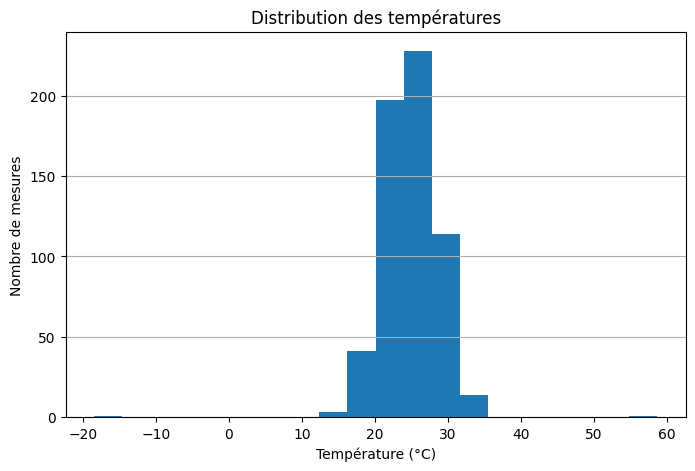

In [23]:
#1) Afficher la distribution des températures en divisant la plage des données en 20 classes 
# #et en affichant uniquement les lignes horizontales de la grille    
plt.figure(figsize=(8, 5))
plt.hist(df["temperature"], bins=20)

plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")

plt.show()  


In [ ]:
# calcue de la mediane et de la moyenne de la temperature
median_temperature = df["temperature"].median()
mean_temperature = df["temperature"].mean()
print(f" Médiane : {median_temperature:.2f} °C")
print(f" Moyenne : {mean_temperature:.2f} °C")

 Médiane : 24.86 °C
 Moyenne : 24.88 °C


## 2): Analyse de l'histogramme des températures


 

## Question 2 : Analyse de l'histogramme des températures

a) Les températures se concentrent entre 20°C et 30°C, avec un pic vers 25-27°C

b) La forme du graphique dessine une cloche assez régulière : les barres montent 
progressivement à partir de 15°C jusqu'au pic vers 25-27°C, puis redescendent 
de façon comparable jusqu'à 35°C. Elle n'est pas parfaitement symétrique (la 
descente à droite du pic semble légèrement plus abrupte que la montée à 
gauche), mais reste globalement équilibrée — ce que confirme la quasi-égalité 
entre moyenne (24.88°C) et médiane (24.86°C), signe caractéristique d'une 
distribution symétrique.

c) Deux valeurs se détachent nettement, isolées vers -18.5°C et 58.7°C.

d) Valeurs aberrantes visibles : ce sont précisément tes deux anomalies de la Partie 1 (le pic à 58°C et le creux à -20°C) — elles apparaîssent comme des barres minuscules, complètement séparées du reste, sur les bords extrêmes du graphique.

## 3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes 


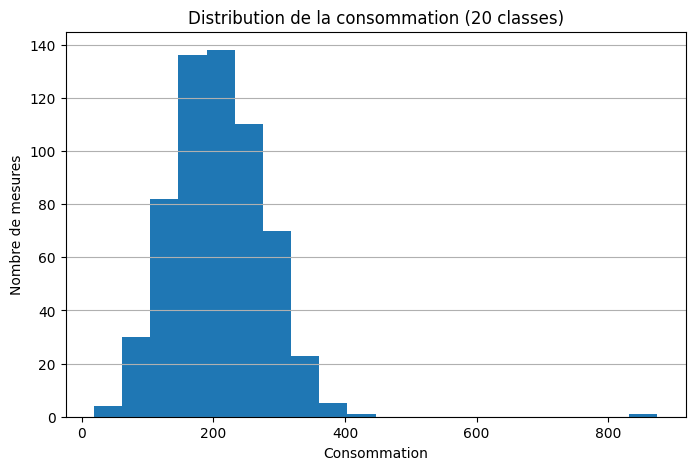

In [24]:
#3) Afficher la distribution de la consommation en divisant la plage des données en 20 classes 
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"], bins=20)
plt.title("Distribution de la consommation (20 classes)")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()

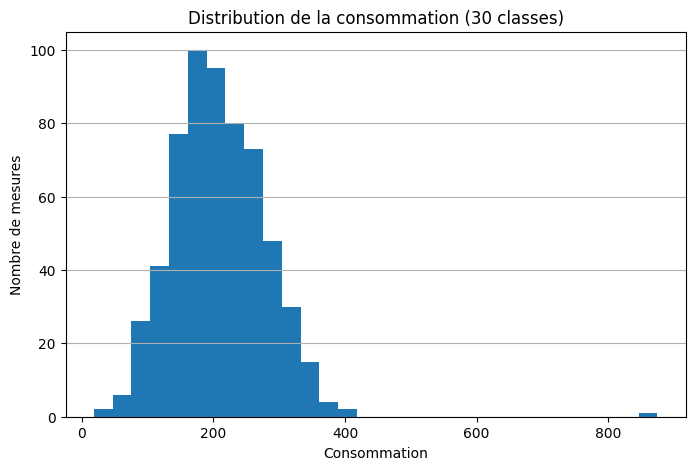

In [25]:
#pour 30 classes
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"], bins=30)
plt.title("Distribution de la consommation (30 classes)")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()

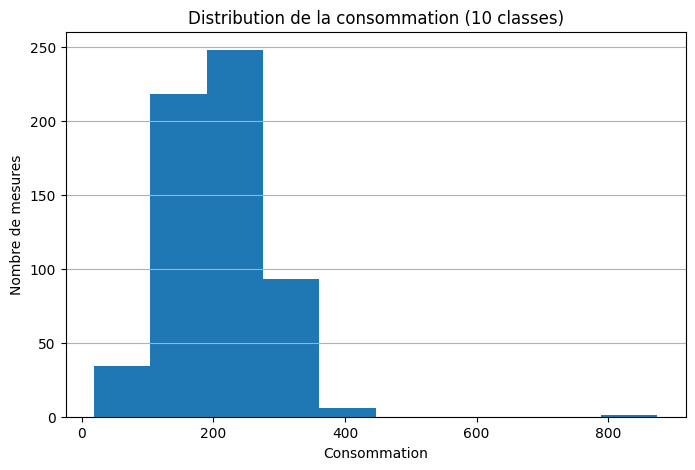

In [26]:
#pour 10 classes
plt.figure(figsize=(8, 5))
plt.hist(df["consommation"], bins=10)
plt.title("Distribution de la consommation (10 classes)")
plt.xlabel("Consommation")
plt.ylabel("Nombre de mesures")
plt.grid(axis="y")
plt.show()


## c) Quel impact le nombre de classes a-t-il sur l'interprétation ? 

Avec 10 classes, la distribution apparaît plus lisse mais moins détaillée — 
plusieurs valeurs proches sont regroupées dans une même barre, ce qui peut 
masquer des nuances. 

Avec 30 classes, on gagne en détail mais le graphique 
devient plus irrégulier, avec des variations d'une barre à l'autre qui ne 
reflètent pas forcément une vraie tendance, juste des fluctuations d'échantillon. 

20 classes offre un bon compromis entre lisibilité et niveau de détail.

# Partie 4 – Nuage de points (Scatter Plot)  
1) Réaliser un nuage de points entre température et consommation 
2) Déterminer visuellement s'il semble exister une relation entre les deux 

## 1) Réaliser un nuage de points entre température et consommation 


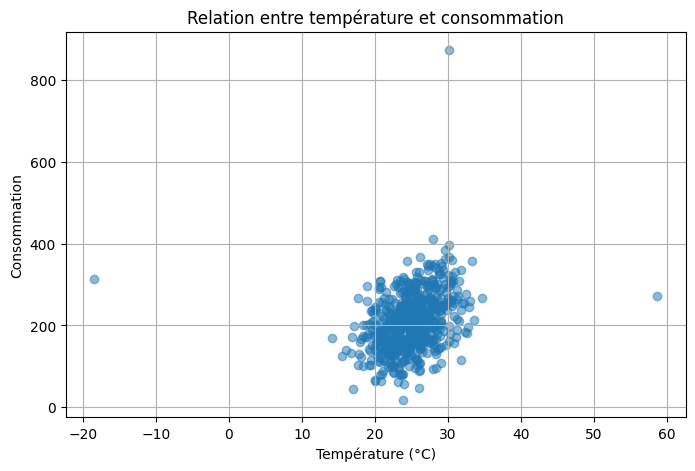

In [27]:
#1) Réaliser un nuage de points entre température et consommation 
plt.figure(figsize=(8, 5))
plt.scatter(df["temperature"], df["consommation"], alpha=0.5)

plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.grid(True)

plt.show()

In [48]:
# calculer le c oefficient de corrélation entre température et consommation

correlation = df["temperature"].corr(df["consommation"])
print(f"Coefficient de corrélation : {correlation:.2f}")

Coefficient de corrélation : 0.32



##  2) : Relation entre température et consommation

Le nuage de points ne montre pas de tendance nette à l'œil.les points 
forment un amas dense sans direction claire. Le calcul du coefficient de 
corrélation confirme cette impression : 0.32, une corrélation positive mais 
faible. Il existe donc une légère tendance (la consommation augmente 
légèrement avec la température), mais la relation reste trop faible pour 
être considérée comme significative.

# Partie 5 – Diagramme à moustache (Box plot) 
1) Créer un box plot de la température. N’oublier pas de supprimer les valeurs manquantes avant de construire le graphique et afficher uniquement les lignes horizontales de la grille 
2) Que représentent les points situés en dehors des moustaches ? 
3) Créer un box plot de la consommation 
4) A partir des deux box plot, comparer :  
  a) la position de la médiane ;  
  b) la taille de la boîte ;  
  c) la longueur des moustaches ;  *
  d) les valeurs extrêmes. 
5) La consommation présente-t-elle davantage de dispersion que la température ? 

## 1) Créer un box plot de la température. N’oublier pas de supprimer les valeurs manquantes avant de construire le graphique et afficher uniquement les lignes horizontales de la grille 

In [31]:
df["temperature"].isnull() .sum()

np.int64(6)

In [32]:
#suppression des valeurs manquantes dans la colonne temperature
temperature_cleaned = df["temperature"].dropna()


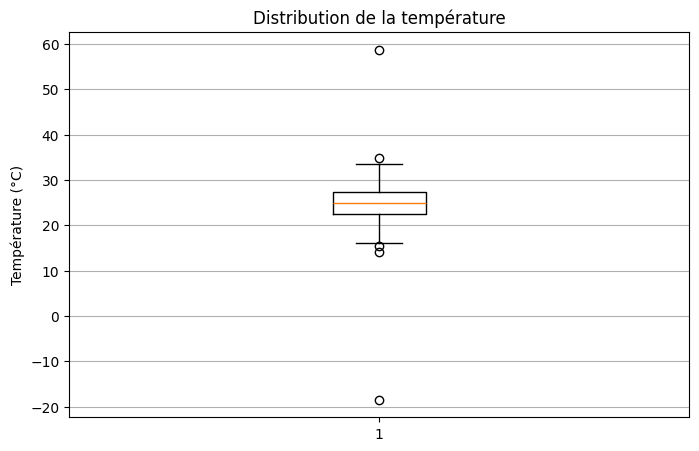

In [35]:
#  Créer un box plot de la température. construire le graphique et afficher uniquement les lignes horizontales de la grille 
plt.figure(figsize=(8, 5))
plt.boxplot(temperature_cleaned)
plt.title("Distribution de la température")
plt.ylabel("Température (°C)")
plt.grid(axis="y")
plt.show()

## 2) Que représentent les points situés en dehors des moustaches ? 


## 2) Que représentent les points situés en dehors des moustaches ? 


Les points situés en dehors des moustaches représentent les valeurs aberrantes 
(outliers) — des mesures anormalement éloignées du reste de la distribution, 
ici probablement les mêmes anomalies déjà identifiées dans les parties précédentes.

In [37]:
df["consommation"].isnull() .sum()  

np.int64(5)

In [38]:
consommation_cleaned = df["consommation"].dropna()

## 3) Créer un box plot de la consommation 


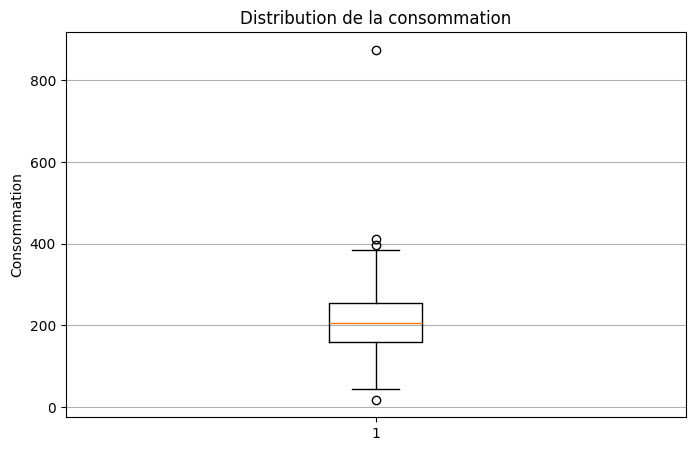

In [40]:
#3) Créer un box plot de la consommation 
plt.figure(figsize=(8, 5))
plt.boxplot(consommation_cleaned)
plt.title("Distribution de la consommation")
plt.ylabel("Consommation")
plt.grid(axis="y")
plt.show()

##  4) : Comparaison des deux box plots


## Question 4 : Comparaison des deux box plots

a)Position de la médiane
Sur les deux box plots, la médiane apparaît centrée au milieu de la boîte : 
pour la température comme pour la consommation, la distance entre la médiane 
et le bord inférieur de la boîte (Q1) est très proche de la distance entre 
la médiane et le bord supérieur (Q3). Les deux distributions sont donc 
équilibrées, sans asymétrie marquée visible sur ce point précis.

b)Taille de la boîte
La boîte de la consommation apparaît nettement plus étendue et plus haute 
que celle de la température — les 50% centraux des données sont donc plus 
dispersés pour la consommation que pour la température.

c)Longueur des moustaches
Les moustaches de la consommation sont également plus longues que celles 
de la température, confirmant une dispersion plus importante sur l'ensemble 
de la distribution (pas seulement au centre).

d)Valeurs extrêmes
On compte 5 points situés en dehors des moustaches pour la température 
(dont deux valeurs très éloignées, environ ~-19°C et ~59°C, et trois plus 
proches des seuils), contre 4 points en dehors des moustaches pour la 
consommation (dont une valeur très éloignée, environ ~875, et trois plus 
proches des seuils). Cette comparaison de nombre de points aberrants est 
un simple comptage, donc valide et interprétable indépendamment de l'échelle 
des deux variables. Les deux variables présentent un nombre comparable 
d'anomalies.



In [43]:
# utiliser la cv pour mesurer la dispersion des données par rapport à la moyenne.
# calcule de la coefficient de variation  en pourcentage
cv = (temperature_cleaned.std() / temperature_cleaned.mean()) * 100
print(f"Coefficient de variation de la température : {cv:.2f}%")

# calcule de la coefficient de variation  en pourcentage
cv = (consommation_cleaned.std() / consommation_cleaned.mean()) * 100
print(f"Coefficient de variation de la consommation : {cv:.2f}")

Coefficient de variation de la température : 16.32%
Coefficient de variation de la consommation : 34.62


## 5) La consommation présente-t-elle davantage de dispersion que la température ? 


## 5) La consommation présente-t-elle davantage de dispersion que la température ? 

Oui  sur les deux box plots, la boîte et les moustaches de la consommation 
sont visiblement plus étendues que celles de la température, ce qui indique 
une dispersion plus importante des données, aussi bien au centre (les 50% 
centraux) que sur l'ensemble de la distribution.

Coefficient de variation de la température  : 16.32%
Coefficient de variation de la consommation : 34.62%

Le coefficient de variation de la consommation est plus du double de celui de 
la température, ce qui confirme que la consommation présente une dispersion 
proportionnellement bien plus importante que la température par rapport à 
leurs moyennes respectives.

# Partie 6 – Diagramme circulaire (Pie Chart) 
1) Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR) 
2) interpréter la proportion de capteurs OK ; proportion ALERTE ;  proportion ERREUR 

## 1) Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR) 


etat
OK        567
ALERTE     29
ERREUR      5
Name: count, dtype: int64


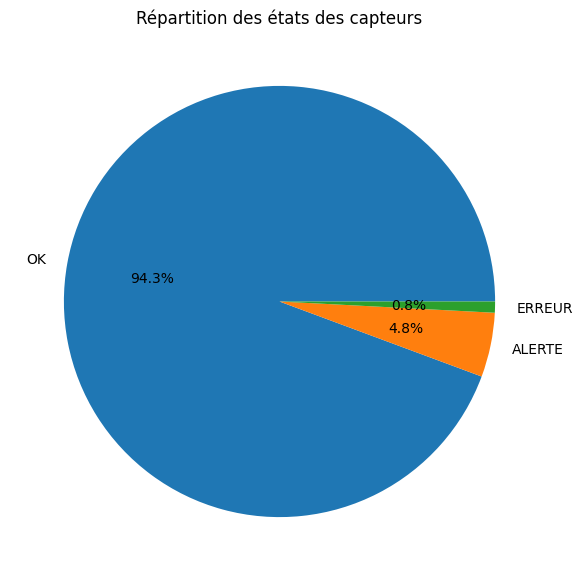

In [44]:
#1) Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR) 
repartition_etat = df["etat"].value_counts()
print(repartition_etat)

plt.figure(figsize=(7, 7))
plt.pie(repartition_etat.values, labels=repartition_etat.index, autopct="%1.1f%%")

plt.title("Répartition des états des capteurs")
plt.show()

## 2) interpréter la proportion de capteurs OK ; proportion ALERTE ;  proportion ERREUR 


## 2) interpréter la proportion de capteurs OK ; proportion ALERTE ;  proportion ERREUR 

La répartition des états montre que 94.3% des mesures sont en état OK, 4.8% 
en ALERTE, et seulement 0.8% en ERREUR. La très grande majorité des capteurs 
fonctionnent donc normalement, avec une faible proportion signalant des 
anomalies (ALERTE + ERREUR = 5.6% au total). Cela suggère un système de 
capteurs globalement fiable, où les situations problématiques restent 
minoritaires mais existent bel et bien.

# Partie 7 : Plusieurs courbes sur un même graphique Construire sur un même graphique  « Évolution de la température par bâtiment" » des quatre bâtiments. 

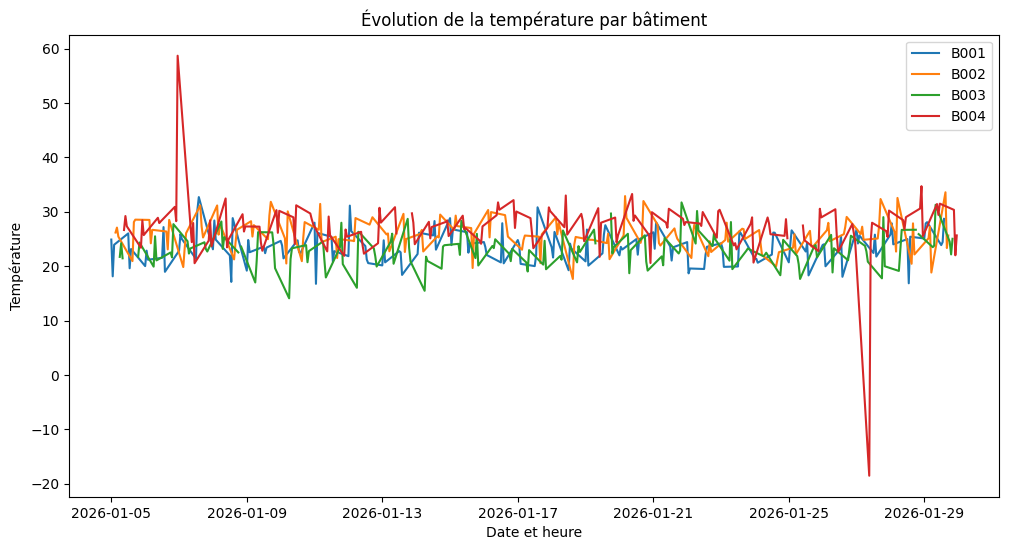

In [45]:
plt.figure(figsize=(12, 6))
for batiment in df["batiment"].unique():
    df_batiment = df[df["batiment"] == batiment]   # pas besoin de re-trier ici
    plt.plot(df_batiment["date_heure"], df_batiment["temperature"], label=batiment)

plt.xlabel("Date et heure")
plt.ylabel("Température")
plt.title("Évolution de la température par bâtiment")
plt.legend()
plt.show()

## interpretation 

La superposition des courbes par bâtiment permet d'identifier que les deux 
anomalies détectées dans la Partie 1 (pic à ~58°C et creux à ~-20°C) 
proviennent toutes les deux du même bâtiment, B004. Cette information n'était 
pas visible dans le graphique global de la Partie 1, où toutes les mesures 
étaient mélangées — cela suggère un possible dysfonctionnement récurrent du 
capteur de ce bâtiment spécifique, plutôt que des erreurs aléatoires réparties 
sur l'ensemble du parc de capteurs.

# Partie 8 : Sauvegarde des graphiques 
1) Sauvegarder le graphique sur l'évolution de la température en fonction du temps  dans exports/ temperature.png 
2) Sauvegarder le graphique sur l'évolution de la température en fonction du temps  dans exports/ temperature.pdf 

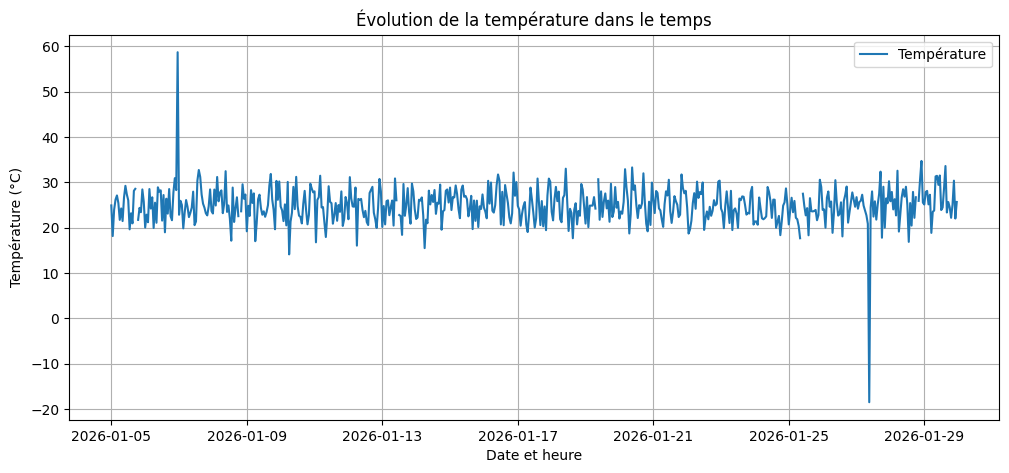

In [46]:
# Dans la Partie 1, tel quel, avec juste 2 lignes ajoutées
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], label="Température")
plt.title("Évolution de la température dans le temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)

plt.savefig("../exports/temperature.png")   # ajouté ici
plt.savefig("../exports/temperature.pdf")   # ajouté ici

plt.show()